# RF 05 — Evaluation

Review common metrics and visualize Actual vs Predicted performance.

In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "random_forest_regressor.yaml"
CONFIG_PATH


WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/random_forest_regressor.yaml')

In [ ]:
from src.ontario_peak_risk.models.forecasting.random_forest.run_model import run_random_forest_regressor
import matplotlib.pyplot as plt
import numpy as np

# results = run_random_forest_regressor(CONFIG_PATH)


In [ ]:
results["global_metrics"]

In [ ]:
results["fold_metrics"]

In [ ]:
results["fsa_metrics"]

In [ ]:
results["horizon_metrics"]

In [ ]:
# MAE by forecast horizon
for fold, group in results["horizon_metrics"].groupby("fold"):
    plt.figure(figsize=(10, 5))
    plt.plot(group["horizon"], group["mae"], marker="o")
    plt.xlabel("Forecast Horizon (hours)")
    plt.ylabel("MAE (kWh)")
    plt.title(f"Random Forest MAE by Forecast Horizon - {fold}")
    plt.xticks(range(1, 25))
    plt.grid(alpha=0.25)
    plt.show()


In [ ]:
# Actual vs Predicted scatter plot
sample = results["predictions"].sample(
    n=min(10000, len(results["predictions"])),
    random_state=42,
)

plt.figure(figsize=(7, 7))
plt.scatter(sample["actual"], sample["predicted"], alpha=0.15)

minimum = min(sample["actual"].min(), sample["predicted"].min())
maximum = max(sample["actual"].max(), sample["predicted"].max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")

plt.xlabel("Actual Consumption (kWh)")
plt.ylabel("Predicted Consumption (kWh)")
plt.title("Random Forest — Actual vs Predicted")
plt.grid(alpha=0.2)
plt.show()


In [ ]:
# Representative 7-day time-series comparison
plot_data = (
    results["predictions"]
    .query("fold == 'fold_2024' and fsa == 'M9W' and horizon == 24")
    .sort_values("forecast_origin")
    .head(24 * 7)
)

plt.figure(figsize=(14, 5))
plt.plot(plot_data["forecast_origin"], plot_data["actual"], label="Actual")
plt.plot(plot_data["forecast_origin"], plot_data["predicted"], label="Predicted")
plt.xlabel("Forecast Origin")
plt.ylabel("Consumption (kWh)")
plt.title("Random Forest — M9W h+24 Actual vs Predicted (Representative Week)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## Additional Error and Residual Analysis

The following diagnostics use the validation predictions already generated by
the Random Forest model. The model is not retrained in this section.

In [5]:
# Load previously generated validation predictions.
# This avoids retraining the Random Forest model.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "modeling"
    / "forecasting"
    / "random_forest"
    / "random_forest_validation_predictions.parquet"
)
PREDICTIONS_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/outputs/modeling/forecasting/random_forest/random_forest_validation_predictions.parquet')

In [7]:
predictions = pd.read_parquet(
    PREDICTIONS_PATH
)

predictions["forecast_origin"] = pd.to_datetime(
    predictions["forecast_origin"]
)

### Residual Distribution

In [8]:
# Residual convention:
# positive residual = model under-predicted demand
# negative residual = model over-predicted demand
predictions["residual"] = (
    predictions["actual"]
    - predictions["predicted"]
)

predictions["absolute_error"] = (
    predictions["residual"].abs()
)

predictions["squared_error"] = (
    predictions["residual"] ** 2
)

print(
    f"Rows loaded: {len(predictions):,}"
)

display(
    predictions.head()
)

Rows loaded: 2,519,424


,fold,fsa,forecast_origin,horizon,actual,predicted,residual,absolute_error,squared_error
0,fold_2023,L4T,2023-01-01 00:00:00,1,8887.8,8397.164009,490.635991,490.635991,240723.676060
1,fold_2023,L4T,2023-01-01 01:00:00,1,8343.7,7903.139103,440.560897,440.560897,194093.904364
2,fold_2023,L4T,2023-01-01 02:00:00,1,8034.0,7760.485642,273.514358,273.514358,74810.103992
3,fold_2023,L4T,2023-01-01 03:00:00,1,7736.1,7627.447170,108.652830,108.652830,11805.437510
4,fold_2023,L4T,2023-01-01 04:00:00,1,7606.8,7646.982258,-40.182258,40.182258,1614.613896


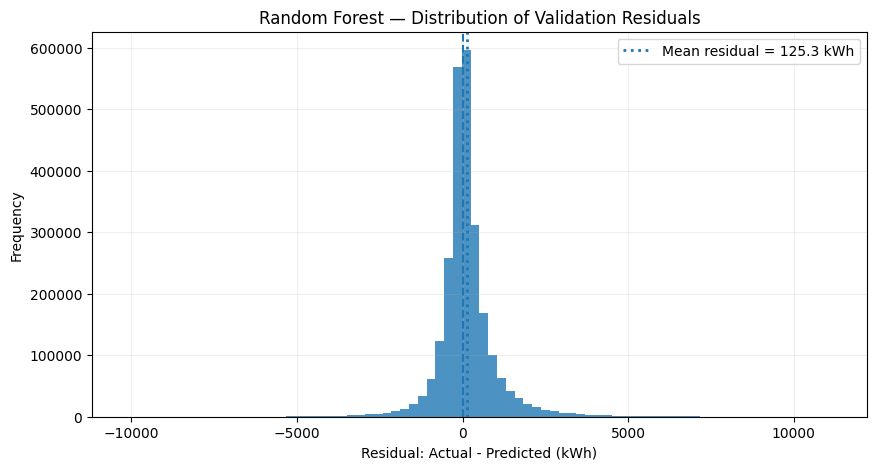

In [9]:
# Plot the overall residual distribution.

plt.figure(figsize=(10, 5))

plt.hist(
    predictions["residual"].dropna(),
    bins=80,
    alpha=0.8,
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
)

plt.axvline(
    predictions["residual"].mean(),
    linestyle=":",
    linewidth=2,
    label=(
        f"Mean residual = "
        f"{predictions['residual'].mean():,.1f} kWh"
    ),
)

plt.xlabel("Residual: Actual - Predicted (kWh)")
plt.ylabel("Frequency")
plt.title(
    "Random Forest — Distribution of Validation Residuals"
)

plt.legend()
plt.grid(alpha=0.2)

plt.show()

### Residual vs Predicted

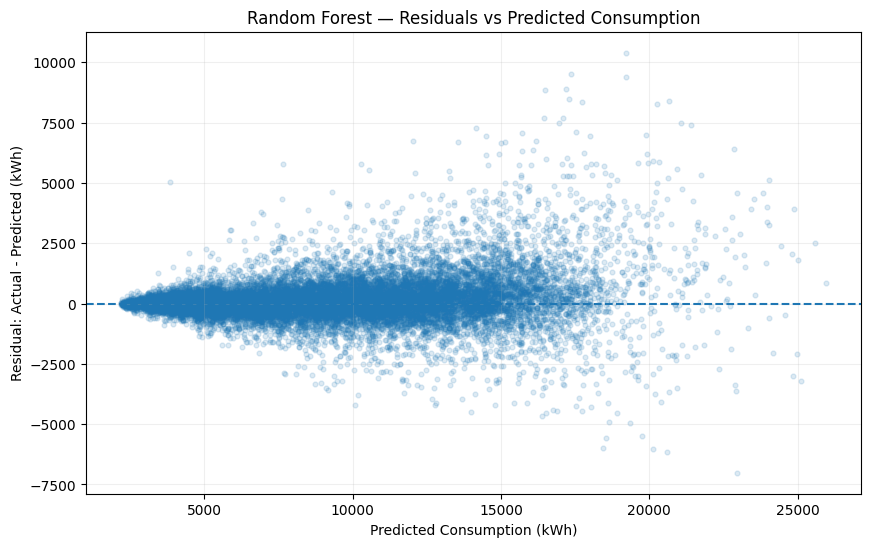

In [10]:
# Plot residuals against predicted electricity demand.

sample = predictions.sample(
    n=min(
        20000,
        len(predictions),
    ),
    random_state=42,
)

plt.figure(figsize=(10, 6))

plt.scatter(
    sample["predicted"],
    sample["residual"],
    alpha=0.15,
    s=12,
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
)

plt.xlabel("Predicted Consumption (kWh)")
plt.ylabel("Residual: Actual - Predicted (kWh)")
plt.title(
    "Random Forest — Residuals vs Predicted Consumption"
)

plt.grid(alpha=0.2)

plt.show()

### Monthly Validation MAE

In [11]:
# Calculate monthly validation error.

predictions["month"] = (
    predictions["forecast_origin"]
    .dt.to_period("M")
    .astype(str)
)

monthly_error = (
    predictions
    .groupby(
        [
            "fold",
            "month",
        ],
        observed=True,
    )
    .agg(
        mae=(
            "absolute_error",
            "mean",
        ),
        mean_residual=(
            "residual",
            "mean",
        ),
        observations=(
            "actual",
            "size",
        ),
    )
    .reset_index()
)

display(
    monthly_error
)

,fold,month,mae,mean_residual,observations
0,fold_2023,2023-01,408.973822,226.381971,107136
1,fold_2023,2023-02,547.150134,180.531092,96768
2,fold_2023,2023-03,426.976897,118.629256,107136
3,fold_2023,2023-04,376.866144,69.026329,103680
4,fold_2023,2023-05,418.260756,170.750578,107136
5,fold_2023,2023-06,752.699545,218.224409,103680
6,fold_2023,2023-07,1185.425094,374.015777,107136
7,fold_2023,2023-08,857.561655,118.145295,107136
8,fold_2023,2023-09,695.377719,264.452814,103680
9,fold_2023,2023-10,397.086716,127.884362,107136


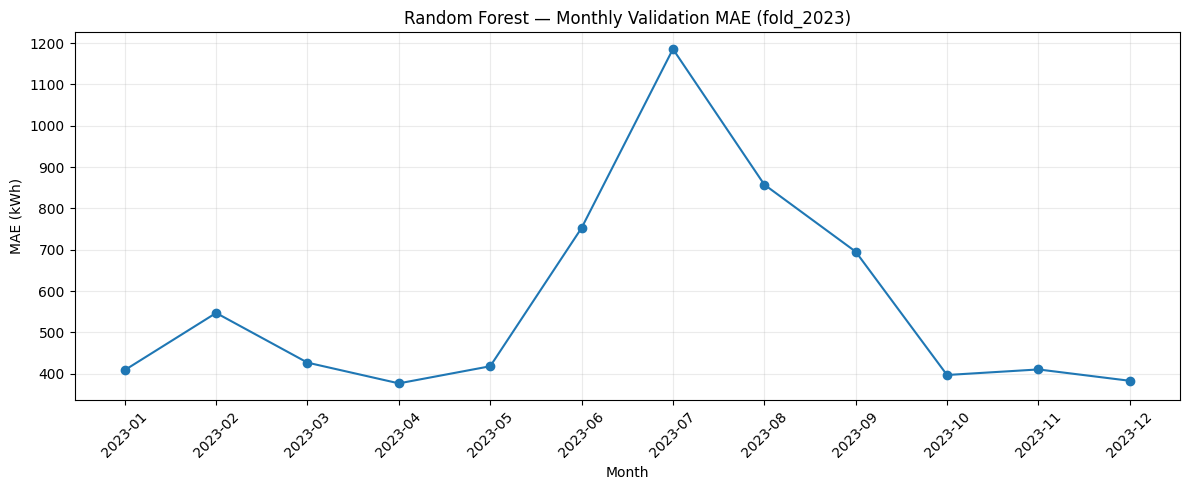

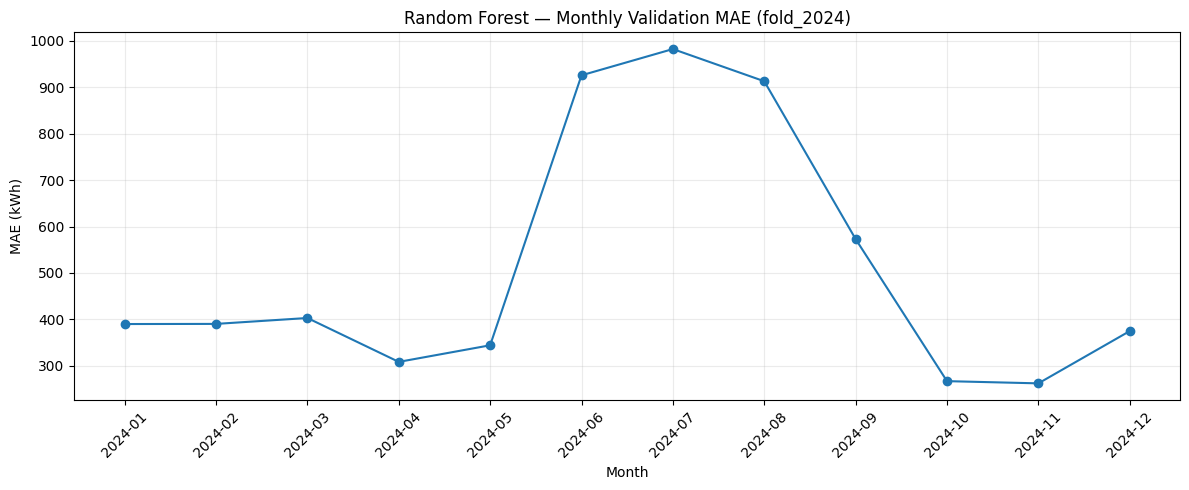

In [12]:
# Plot monthly MAE across each validation period.

for fold, group in monthly_error.groupby(
    "fold"
):

    plt.figure(figsize=(12, 5))

    plt.plot(
        group["month"],
        group["mae"],
        marker="o",
    )

    plt.xlabel("Month")
    plt.ylabel("MAE (kWh)")
    plt.title(
        f"Random Forest — Monthly Validation MAE ({fold})"
    )

    plt.xticks(
        rotation=45
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

### Annual Actual vs Predicted Timeline

In [13]:
# Aggregate hourly predictions to daily mean demand.

predictions["date"] = (
    predictions["forecast_origin"]
    .dt.floor("D")
)

daily_validation = (
    predictions
    .groupby(
        [
            "fold",
            "date",
        ],
        observed=True,
    )
    .agg(
        actual_mean=(
            "actual",
            "mean",
        ),
        predicted_mean=(
            "predicted",
            "mean",
        ),
    )
    .reset_index()
)

daily_validation["residual"] = (
    daily_validation["actual_mean"]
    - daily_validation["predicted_mean"]
)

daily_validation.head()

,fold,date,actual_mean,predicted_mean,residual
0,fold_2023,2023-01-01,8485.108825,8707.805251,-222.696425
1,fold_2023,2023-01-02,8723.019155,8521.359577,201.659578
2,fold_2023,2023-01-03,9000.432957,8751.053219,249.379738
3,fold_2023,2023-01-04,9161.086806,8917.047378,244.039428
4,fold_2023,2023-01-05,9118.731279,8912.250319,206.480960


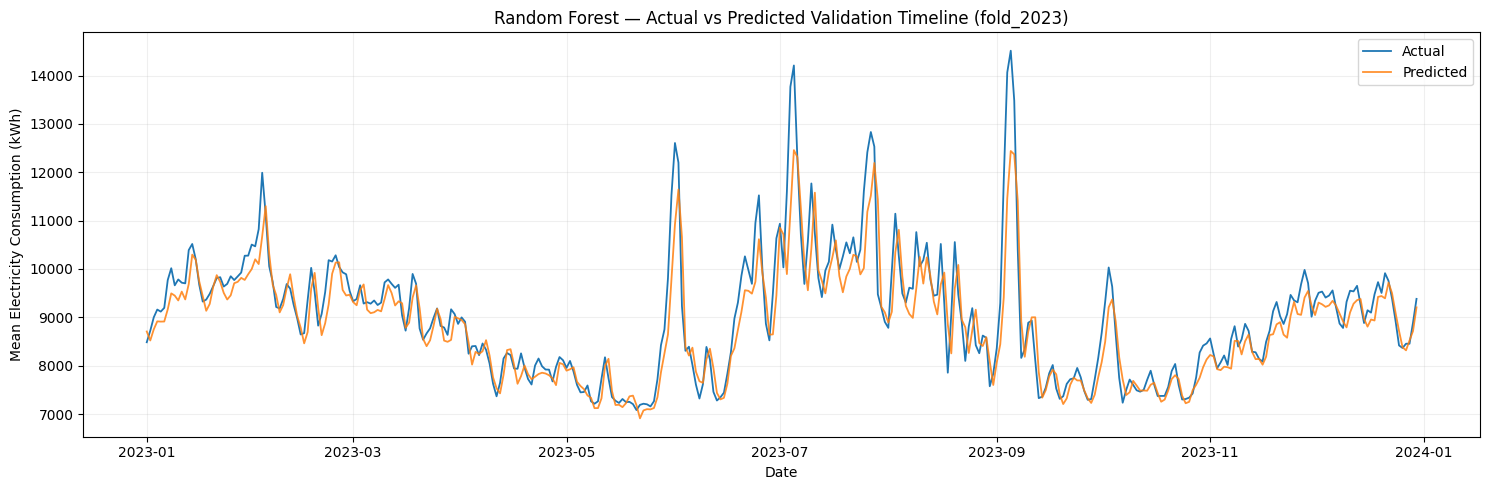

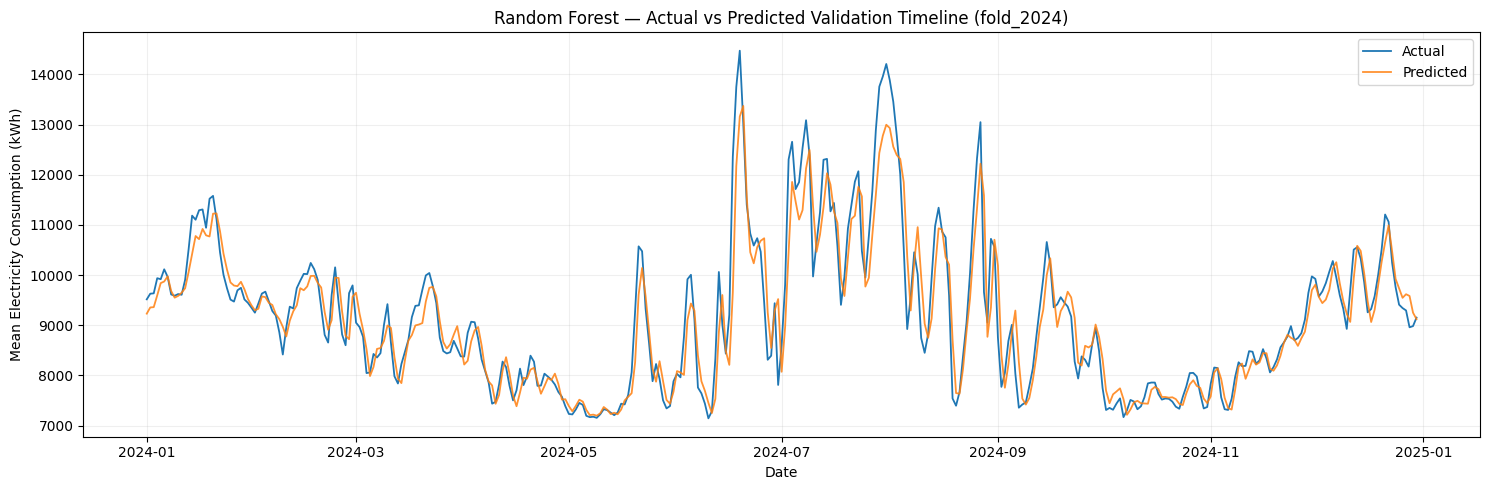

In [14]:
# Plot the full validation-year timeline using daily mean demand.

for fold, group in daily_validation.groupby(
    "fold"
):

    plt.figure(
        figsize=(15, 5)
    )

    plt.plot(
        group["date"],
        group["actual_mean"],
        label="Actual",
        linewidth=1.3,
    )

    plt.plot(
        group["date"],
        group["predicted_mean"],
        label="Predicted",
        linewidth=1.3,
        alpha=0.85,
    )

    plt.xlabel("Date")
    plt.ylabel(
        "Mean Electricity Consumption (kWh)"
    )

    plt.title(
        f"Random Forest — "
        f"Actual vs Predicted Validation Timeline ({fold})"
    )

    plt.legend()
    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

### Residual Timeline

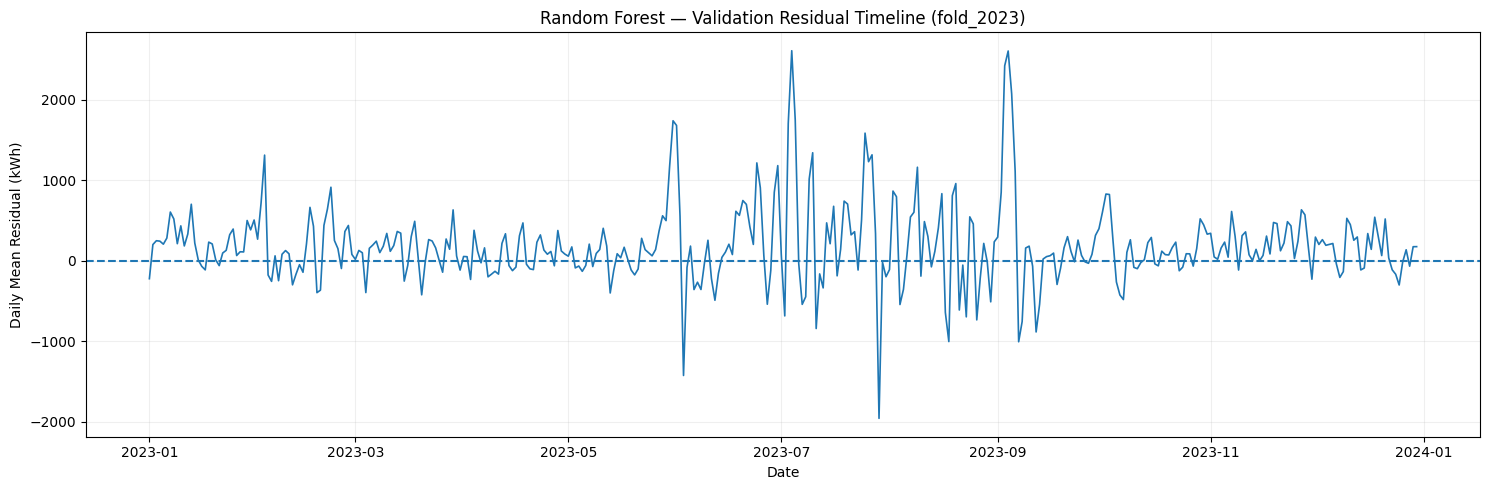

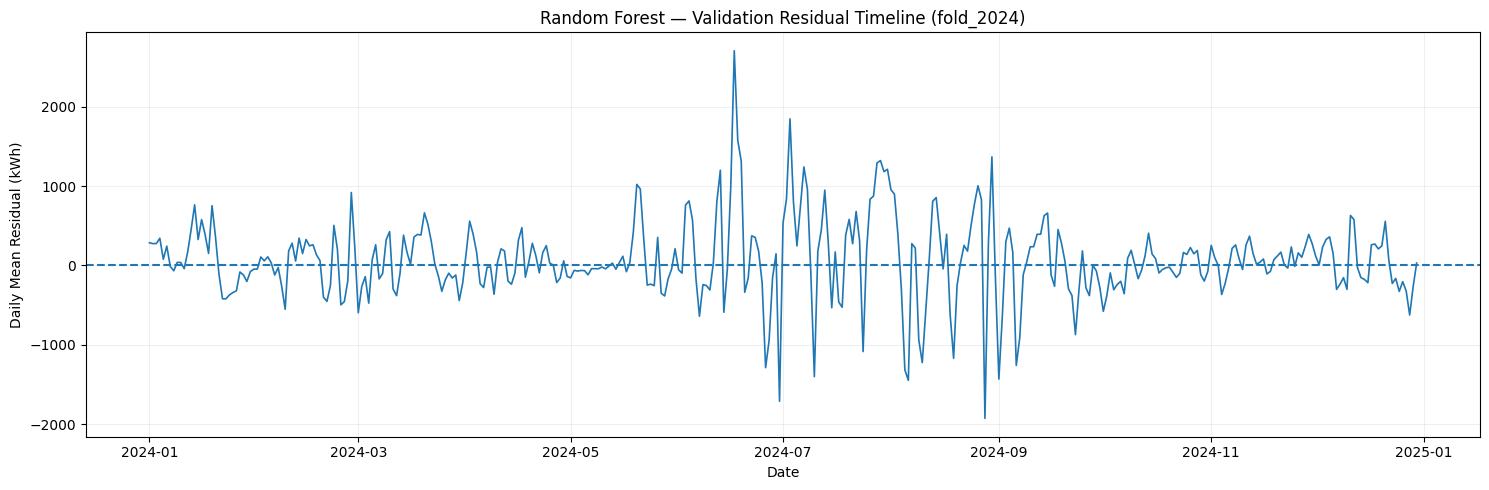

In [15]:
# Plot daily mean residuals throughout the validation year.

for fold, group in daily_validation.groupby(
    "fold"
):

    plt.figure(
        figsize=(15, 5)
    )

    plt.plot(
        group["date"],
        group["residual"],
        linewidth=1.2,
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1.5,
    )

    plt.xlabel("Date")
    plt.ylabel(
        "Daily Mean Residual (kWh)"
    )

    plt.title(
        f"Random Forest — "
        f"Validation Residual Timeline ({fold})"
    )

    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

### Residuals by FSA

C:\Users\jocub\AppData\Local\Temp\ipykernel_17352\2258872467.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


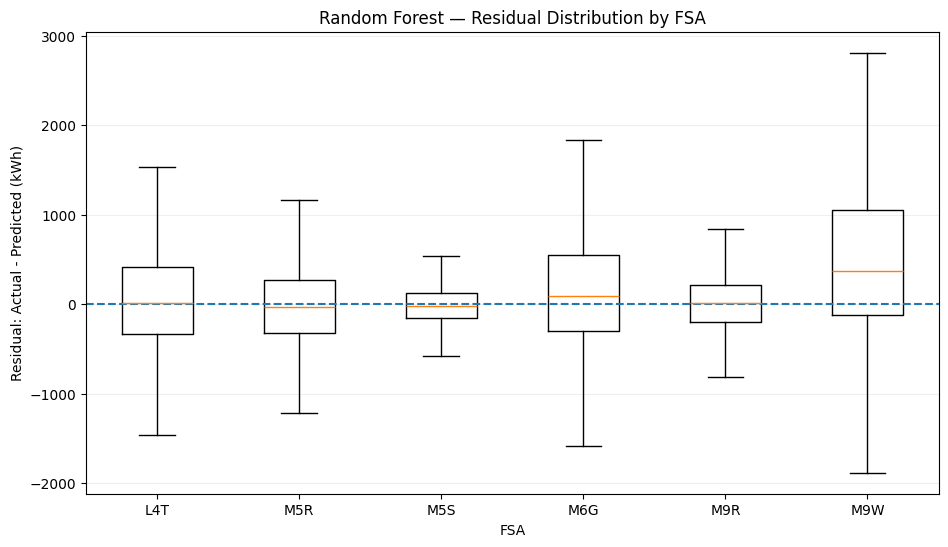

In [16]:
# Compare residual distributions across FSAs.

fsa_order = sorted(
    predictions["fsa"]
    .dropna()
    .unique()
)

fsa_residual_data = [
    predictions.loc[
        predictions["fsa"] == fsa,
        "residual",
    ].dropna()
    for fsa in fsa_order
]

plt.figure(
    figsize=(11, 6)
)

plt.boxplot(
    fsa_residual_data,
    labels=fsa_order,
    showfliers=False,
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
)

plt.xlabel("FSA")
plt.ylabel(
    "Residual: Actual - Predicted (kWh)"
)

plt.title(
    "Random Forest — Residual Distribution by FSA"
)

plt.grid(
    axis="y",
    alpha=0.2,
)

plt.show()

### Error by FSA and Month — heatmap

In [17]:
# Calculate monthly MAE by FSA.

fsa_monthly_mae = (
    predictions
    .groupby(
        [
            "fsa",
            "month",
        ],
        observed=True,
    )["absolute_error"]
    .mean()
    .reset_index(
        name="mae"
    )
)

fsa_monthly_pivot = (
    fsa_monthly_mae
    .pivot(
        index="fsa",
        columns="month",
        values="mae",
    )
)

display(
    fsa_monthly_pivot
)

month,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,...,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
fsa,,,,,,,,,,,,,,,,,,,,,
L4T,312.030493,471.759178,371.200708,386.450361,459.846646,1015.508936,1437.017306,1173.804300,875.755498,401.491563,...,425.501468,335.155147,524.958866,1357.798887,1389.822818,1349.821584,874.049018,319.308208,291.329633,384.383819
M5R,347.680453,594.848372,440.961563,351.388149,270.748373,436.097457,717.927985,535.015111,450.727341,307.337476,...,435.421477,300.044733,250.138762,661.560847,624.172517,620.640189,389.067952,236.611449,260.051825,422.428022
M5S,170.305931,264.791160,209.935560,171.036000,130.876103,201.666085,289.616574,241.536652,213.829040,140.328589,...,199.007841,147.226616,120.617080,280.046357,261.159626,277.403294,194.677933,119.139459,139.436514,208.977477
M6G,465.961966,715.476738,546.782880,433.621629,401.483887,779.809421,1236.332131,825.086452,740.771013,428.161845,...,590.115825,430.349150,372.335284,1048.851437,1080.103932,1052.116754,691.044506,342.928154,365.502393,541.106250
M9R,200.091767,285.796943,224.158525,229.176261,258.180377,539.028856,856.006390,658.055311,478.063046,250.180300,...,253.734160,204.902835,264.592067,738.022459,834.946865,725.351404,445.121154,197.679073,177.429974,226.526874
M9W,957.772325,950.228412,768.822150,689.524463,988.429149,1544.086515,2575.650177,1711.872104,1413.120375,855.020521,...,513.622698,432.414750,532.027744,1468.350747,1703.890880,1452.476559,843.815273,385.466324,338.754746,464.917676


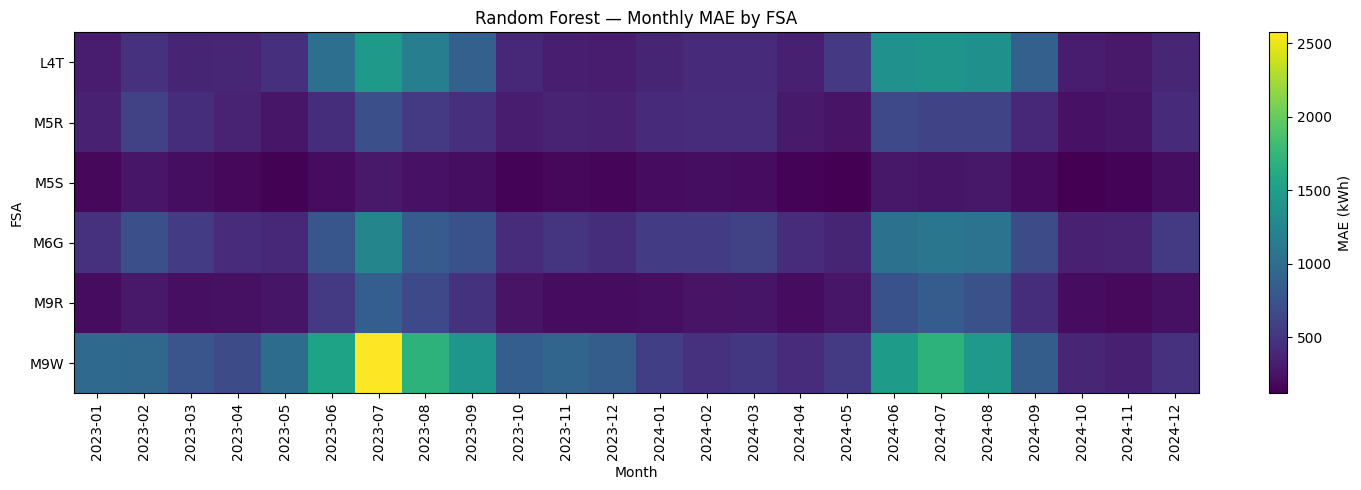

In [18]:
# Heatmap of MAE by FSA and month.

fig, ax = plt.subplots(
    figsize=(15, 5)
)

image = ax.imshow(
    fsa_monthly_pivot.values,
    aspect="auto",
)

ax.set_yticks(
    range(
        len(
            fsa_monthly_pivot.index
        )
    )
)

ax.set_yticklabels(
    fsa_monthly_pivot.index
)

ax.set_xticks(
    range(
        len(
            fsa_monthly_pivot.columns
        )
    )
)

ax.set_xticklabels(
    fsa_monthly_pivot.columns,
    rotation=90,
)

ax.set_xlabel("Month")
ax.set_ylabel("FSA")

ax.set_title(
    "Random Forest — Monthly MAE by FSA"
)

fig.colorbar(
    image,
    ax=ax,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()

### Summary of Residuals 

In [19]:
# Summarize residual behavior by validation fold.

residual_summary = (
    predictions
    .groupby(
        "fold",
        observed=True,
    )
    .agg(
        mean_residual=(
            "residual",
            "mean",
        ),
        median_residual=(
            "residual",
            "median",
        ),
        residual_std=(
            "residual",
            "std",
        ),
        mae=(
            "absolute_error",
            "mean",
        ),
        p95_absolute_error=(
            "absolute_error",
            lambda values: values.quantile(0.95),
        ),
        maximum_absolute_error=(
            "absolute_error",
            "max",
        ),
    )
    .reset_index()
)

display(
    residual_summary
)

,fold,mean_residual,median_residual,residual_std,mae,p95_absolute_error,maximum_absolute_error
0,fold_2023,185.472987,47.580553,975.119442,572.528742,1991.239896,11145.695040
1,fold_2024,65.316194,17.050938,852.327931,512.064401,1794.721684,10127.567086
